<a href="https://colab.research.google.com/github/Akash981885/projectX/blob/features/exercises/machine-learning/supervised-learning/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression
You should build a machine learning pipeline using a linear regression model. In particular, you should do the following:
- Load the `housing` dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the datasets folder.
- Split the dataset into training and test sets using [Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).
- Conduct data exploration, data preprocessing, and feature engineering if necessary.
- Train and test a linear regression model using [Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score



In [33]:

df = pd.read_csv("https://raw.githubusercontent.com/m-mahdavi/teaching/main/datasets/housing.csv")
df.head ()

,id,price,area,bedrooms,bathrooms,stories,stories.1,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


In [34]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)


In [35]:
print(df.dtypes)
print("\n")
print(df.info())
print("\n")
print(df.describe())


id                    int64
price                 int64
area                  int64
bedrooms              int64
bathrooms             int64
stories               int64
stories.1             int64
guestroom             int64
basement              int64
hotwaterheating       int64
airconditioning       int64
parking               int64
prefarea              int64
furnishingstatus    float64
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                545 non-null    int64  
 1   price             545 non-null    int64  
 2   area              545 non-null    int64  
 3   bedrooms          545 non-null    int64  
 4   bathrooms         545 non-null    int64  
 5   stories           545 non-null    int64  
 6   stories.1         545 non-null    int64  
 7   guestroom         545 non-null    int64  
 8   basement    

In [59]:
print(df.head())
print("\n")
print(df.tail())
print("\n")
print(df.shape)
print("\n")
print(df.columns)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head()


   id     price  area  bedrooms  bathrooms  stories  stories.1  guestroom  \
0   0  13300000  7420         4          2        3          1          0   
1   1  12250000  8960         4          4        4          1          0   
2   2  12250000  9960         3          2        2          1          0   
3   3  12215000  7500         4          2        2          1          0   
4   4  11410000  7420         4          1        2          1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0               1.0  
1               1.0  
2               0.5  
3               1.0  
4               1.

,id,price,area,bedrooms,bathrooms,stories,stories.1,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


In [56]:
print(df.index)
print("\n")
print(df.isnull().sum())
print("\n")
print(df.duplicated().sum())

RangeIndex(start=0, stop=545, step=1)


id                  0
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
stories.1           0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


0


In [37]:
x = df.drop('price', axis=1)
y = df['price']


In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
def add_features(df):
  df = df.copy()
  df['rooms_per_household'] = df['total_rooms'] / df['households']
  df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
  df['population_per_household'] = df['population'] / df['households']
  return df

  feature_engineering = FunctionTransformer(add_features, validate=False)
  print(feature_engineering)


In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [74]:
y_pred = model.predict(x_test)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#df_pred = pd.DataFrame(y_pred, columns=['Predicted Price'])
#df_pred.head(10)
print(y_pred)



[4658263.85126968 7112378.61190028 3582242.26814179 6372394.28195417
 2273077.56728105 5098795.775266   5793351.123663   5068918.7447866
 2229277.11677719 2983277.34341527 8528431.90977453 2287030.17560666
 3242443.51917211 3045633.15503653 1976286.08143129 3128432.61593703
 2272084.41009526 6861765.46845404 2648959.30586942 2439877.85363414
 6821453.78904241 5657359.94885174 1887027.96068752 5516893.77262268
 4497715.55227301 7908268.57690709 2458022.34766398 5527666.24578732
 7659106.41778797 2153684.35970601 6994948.72167159 3363400.96923551
 6881504.05532823 2534632.64437884 2986978.93138023 4897006.92902718
 5170494.7363008  3002077.21974964 3480260.612054   2391594.5672508
 5827209.538749   3655130.41981735 7119469.96093766 5264693.0695424
 2796872.26785892 4902340.20179457 7001949.97755147 5863259.67501635
 2642208.43605974 2012849.60721012 7786926.12507166 2176814.9341839
 4515660.79997142 4179662.54791455 2793475.06503562 1873168.55929929
 7873933.57035961 1943742.7945071  450

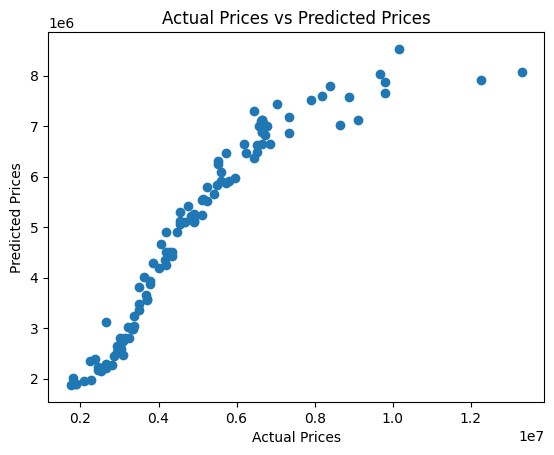

In [51]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()